# Test the trained AutoML Forecasting model

This notebook loads the AutoML **forecasting** model exported from Azure Machine Learning and generates a **7-day daily forecast**.

## Model summary (auto-detected from `MLmodel`)

- Model type: AutoML Forecasting (scikit-learn flavor)
- Time column: `Date`
- Target (dependent variable): `NT (mm)`
- Feature columns: `NT (hr)`, `ST (mm)`, `ST (hr)`, `WR (mm)`, `WR (hr)`
- Frequency: daily | Forecast horizon: 7 days
- Loaded with: `mlflow.pyfunc.load_model(...)`

## How to use

1. Run the cells in order.
2. Put this notebook in the same folder as the exported model files (`MLmodel`, `model.pkl`, `conda.yaml`, `requirements.txt`, `python_env.yaml`) or set `MODEL_DIR` below to the model folder path.
3. Set `TEST_DATA_PATH` to the CSV with the rows you want to forecast. The model rejects rows dated inside the training period (2021-01-01 to 2026-06-30), so the CSV should contain only FUTURE-dated rows (e.g. 2026-07-01 to 2026-07-07) with the feature columns, plus a placeholder `NT (mm)` column (its values are ignored).
4. The last cells print and plot the forecast for the dates in your CSV.

## Important - matching environment

The model was **trained on Python 3.10** with the package versions pinned in `conda.yaml` (e.g. `cmdstanpy==1.0.4`, `scikit-learn==1.5.1`, `pandas==1.5.3`). Loading `model.pkl` on a different Python/version (e.g. the Python 3.8 `azureml_py38` kernel) fails with errors like `Can't get attribute 'BaseType' on ... cmdstanpy.utils`. On the compute instance terminal, create a matching kernel and run this notebook with it:

    conda env create -f conda.yaml -n automl-forecast

Then restart the notebook and select the **automl-forecast** (Python 3.10) kernel.


In [1]:
# Install the packages needed to load this AutoML forecasting model.
# IMPORTANT: the model was trained on Python 3.10 with the exact versions pinned
# in conda.yaml (e.g. cmdstanpy==1.0.4, scikit-learn==1.5.1, pandas==1.5.3).
# The best approach is to create a matching conda environment from the exported
# conda.yaml and run this notebook with that (Python 3.10) kernel:
#     conda env create -f conda.yaml -n automl-forecast
# On an Azure ML compute instance the packages are usually already installed.
# Set SKIP_INSTALL = True to skip this step.

SKIP_INSTALL = False

if not SKIP_INSTALL:
    import subprocess, sys
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet",
        "mlflow==2.15.1",
        "azureml-training-tabular==1.61.0",
        "scikit-learn==1.5.1",
        "pandas==1.5.3",
        "cmdstanpy==1.0.4",
        "matplotlib",
    ])
    print("Packages installed.")
else:
    print("Skipped package installation.")

Packages installed.


In [2]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import mlflow

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

# Folder that contains the exported model files (MLmodel, model.pkl, ...).
MODEL_DIR = "."

# CSV with the data you want to forecast from. It must contain the 'Date'
# column and the feature columns the model was trained on.
TEST_DATA_PATH = "test.csv"

# Expected column names (from the training schema).
TIME_COLUMN = "Date"
TARGET_COLUMN = "NT (mm)"

In [3]:
import sys

print("Python:", sys.version.split()[0])
if sys.version_info < (3, 9):
    print("WARNING: this model was trained on Python 3.10 (see conda.yaml) and")
    print("scikit-learn 1.5.1 requires Python >= 3.9. Running on this Python")
    print("version is likely to fail. Create a matching kernel first:")
    print("    conda env create -f conda.yaml -n automl-forecast")
    print("then re-open this notebook with the 'automl-forecast' (Python 3.10) kernel.")

# Load the model as an MLflow pyfunc model. This uses the python_function
# flavor, which knows how to run AutoML forecasting predictions.
try:
    model = mlflow.pyfunc.load_model(MODEL_DIR)
    print("Model loaded successfully from:", os.path.abspath(MODEL_DIR))
    print("Loader module:", model.metadata.flavors.get("python_function", {}).get("loader_module"))
except AttributeError as exc:
    print()
    print("ERROR:", exc)
    print()
    print("The model was pickled with the exact package versions in conda.yaml")
    print("(cmdstanpy==1.0.4, scikit-learn==1.5.1, pandas==1.5.3, python 3.10).")
    print("This environment has different versions, so pickle cannot restore it.")
    print()
    print("Fix - create a matching environment and run with that kernel:")
    print("    conda env create -f conda.yaml -n automl-forecast")
    print("(quick, partial test on this env:  pip install cmdstanpy==1.0.4)")
    raise

Python: 3.10.11
Model loaded successfully from: /mnt/batch/tasks/shared/LS_root/mounts/clusters/onesvm/code/Users/onesinus231
Loader module: azureml.training.tabular.models.mlflow.timeseries


2026/08/10 04:56:41 WARNING mlflow.utils.requirements_utils: Encountered an unexpected error (TypeError('expected string or bytes-like object')) while detecting model dependency mismatches. Set logging level to DEBUG to see the full traceback.


In [4]:
# Show the MLflow metadata for reference. Note: the MLmodel file is YAML,
# not JSON, so it is parsed with pyyaml here.
try:
    import yaml
    with open(os.path.join(MODEL_DIR, "MLmodel"), encoding="utf-8-sig") as fh:
        mlmodel_meta = yaml.safe_load(fh)
    print(yaml.safe_dump(mlmodel_meta, sort_keys=False))
except ImportError:
    print("pyyaml not installed; skipping the MLmodel summary.")
except Exception as exc:
    print("(could not parse MLmodel:", exc, ")")

# Best-effort: read the AutoML time-series configuration from the model.
try:
    impl = getattr(model, "_model_impl", model)
    ts_params = getattr(impl, "timeseries_param_dict", None)
    if ts_params is None and getattr(impl, "_timeseries", None) is not None:
        ts_params = impl._timeseries.timeseries_param_dict
    if ts_params:
        print("\nTime-series configuration detected:")
        for key in ("time_column_name", "target_column_name", "grain_column_names",
                    "max_horizon", "frequency", "target_lags", "target_rolling_window_size"):
            if key in ts_params:
                print(f"  {key}: {ts_params[key]}")
except Exception as exc:  # introspection is best-effort
    print("(could not introspect time-series config:", exc, ")")

artifact_path: outputs/mlflow-model
flavors:
  automl-forecasting:
    forecasting_model_type: fc.model_type.sklearn
  python_function:
    env:
      conda: conda.yaml
      virtualenv: python_env.yaml
    loader_module: azureml.training.tabular.models.mlflow.timeseries
    model_path: model.pkl
    predict_fn: predict
    python_version: 3.10.19
  sklearn:
    code: null
    pickled_model: model.pkl
    serialization_format: pickle
    sklearn_version: 1.5.1
metadata:
  azureml.base_image: mcr.microsoft.com/azureml/curated/ai-ml-automl:41
  azureml.engine: automl
mlflow_version: 2.15.1
model_size_bytes: 679414
model_uuid: e237a235b326477f848060838feb2fd8
run_id: automl_nt_daily_20
utc_time_created: '2026-07-22 07:27:00.021639'



In [5]:
if not os.path.exists(TEST_DATA_PATH):
    raise FileNotFoundError(
        f"Test data not found: {TEST_DATA_PATH!r}\n"
        "Put your CSV next to this notebook or update TEST_DATA_PATH above."
    )

df_test = pd.read_csv(TEST_DATA_PATH, encoding="utf-8-sig")
df_test[TIME_COLUMN] = pd.to_datetime(df_test[TIME_COLUMN])

print("Rows:", len(df_test))
print("Columns:", list(df_test.columns))
print("Date range:", df_test[TIME_COLUMN].min(), "->", df_test[TIME_COLUMN].max())
print("\nFirst rows:")
df_test.head()

Rows: 7
Columns: ['Date', 'NT (mm)', 'NT (hr)', 'ST (mm)', 'ST (hr)', 'WR (mm)', 'WR (hr)']
Date range: 2026-07-01 00:00:00 -> 2026-07-07 00:00:00

First rows:


,Date,NT (mm),NT (hr),ST (mm),ST (hr),WR (mm),WR (hr)
0,2026-07-01,0.10,0.00,2.60,1.40,0.80,0.60
1,2026-07-02,0.00,0.00,3.90,2.40,1.30,1.20
2,2026-07-03,0.10,0.10,0.10,0.10,1.50,0.80
3,2026-07-04,0.30,0.20,0.00,0.00,0.90,0.60
4,2026-07-05,0.10,0.00,0.00,0.00,1.90,1.50


In [6]:
# Expected input columns (from the training data schema).
EXPECTED_COLUMNS = [
    TIME_COLUMN,
    TARGET_COLUMN,
    "NT (hr)",
    "ST (mm)",
    "ST (hr)",
    "WR (mm)",
    "WR (hr)",
]

missing = [c for c in EXPECTED_COLUMNS if c not in df_test.columns]
if missing:
    print("WARNING - these expected columns are not in the CSV:")
    for c in missing:
        print("   -", c)
    print("The prediction may fail if the model needs them.")

# Keep only the columns the model understands (extra columns are ignored).
cols = [c for c in EXPECTED_COLUMNS if c in df_test.columns]
df_input = df_test[cols].copy()
print("Input shape for prediction:", df_input.shape)

Input shape for prediction: (7, 7)


In [7]:
# Generate the forecast. AutoML forecasting predicts 'max_horizon' (7) daily
# steps after the training data end. The input rows must be dated AFTER the
# last training date (2026-06-30) - AutoML rejects rows inside the training
# period with a ForecastingDataException.
try:
    y_pred = model.predict(df_input)
except Exception as exc:
    if "ForecastingDataException" in type(exc).__name__ or "dates prior to the latest date" in str(exc):
        print()
        print("The model rejected the prediction input because it contains dates")
        print("inside the training period. test.csv must contain ONLY future-dated")
        print("rows (after the last training date) for the dates you want to forecast.")
        print("Fix test.csv, then re-run from the cell that reads the CSV.")
    raise

# Normalise the output to a DataFrame indexed by forecast date.
if isinstance(y_pred, pd.Series):
    forecast = y_pred.rename(TARGET_COLUMN).to_frame()
elif isinstance(y_pred, pd.DataFrame):
    forecast = y_pred.copy()
    if TARGET_COLUMN not in forecast.columns:
        forecast = forecast.rename(columns={forecast.columns[0]: TARGET_COLUMN})
else:  # ndarray / list -> build dates from the last observed date
    last_date = df_input[TIME_COLUMN].max()
    n_steps = len(np.asarray(y_pred).ravel())
    dates = pd.date_range(start=last_date, periods=n_steps + 1, freq="D")[1:]
    forecast = pd.DataFrame({TARGET_COLUMN: np.asarray(y_pred).ravel()}, index=dates)

forecast.index.name = "forecast_date"
print("Forecast generated:", forecast.shape[0], "steps")
forecast

Forecast generated: 7 steps


,NT (mm)
forecast_date,
2026-07-08,0.10
2026-07-09,0.00
2026-07-10,0.10
2026-07-11,0.30
2026-07-12,0.10
2026-07-13,0.20
2026-07-14,0.20


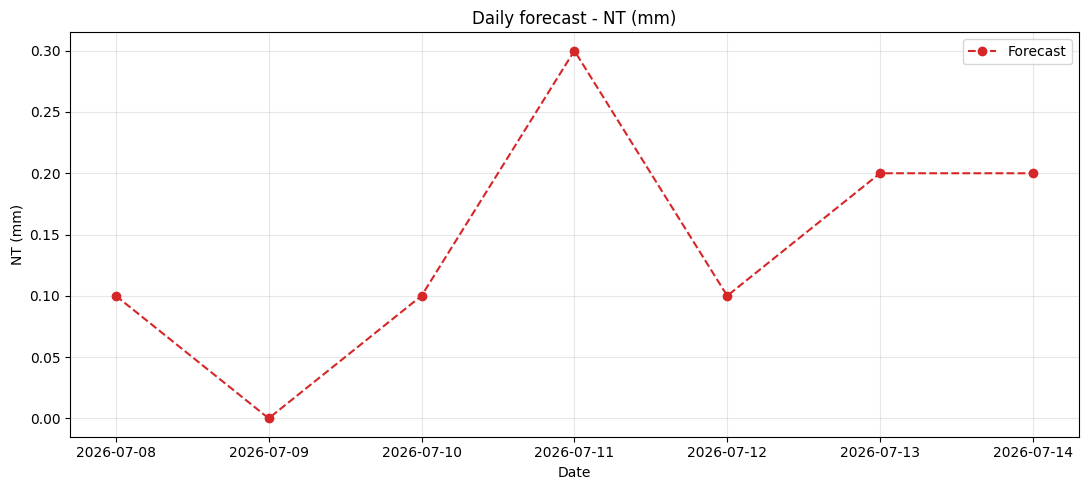

Forecast saved to: forecast_output.csv


In [8]:
fig, ax = plt.subplots(figsize=(11, 5))

# If the test CSV contains observed history (target values across many rows),
# plot it for context. A short future-only window has no history to show.
has_history = (TARGET_COLUMN in df_test.columns) and (len(df_test) > len(forecast) + 30)
if has_history:
    hist = df_test.tail(60)
    ax.plot(hist[TIME_COLUMN], hist[TARGET_COLUMN], marker=".", label="History (observed)")

ax.plot(forecast.index, forecast[TARGET_COLUMN], marker="o", linestyle="--",
        color="tab:red", label="Forecast")

ax.set_title(f"Daily forecast - {TARGET_COLUMN}")
ax.set_xlabel("Date")
ax.set_ylabel(TARGET_COLUMN)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save the forecast to a CSV.
forecast.to_csv("forecast_output.csv", encoding="utf-8-sig")
print("Forecast saved to: forecast_output.csv")

## Interpreting the results

- The output is the model's forecast for the **dates in your CSV**. Those dates must be after the training data end (2026-06-30); the model forecasts up to `max_horizon` = 7 daily steps from there.
- This is a **forecasting** model: the forecast is produced from the end of the history you provide, not row-by-row.
- `target_lags` and rolling-window features were **not** used in this model, so the forecast depends mainly on the feature columns and the date-based features (day of week, month, ...) the model creates internally.
- To forecast further ahead, add future-dated rows (with the feature values) to your CSV and re-run.
- Your CSV should include the `NT (mm)` column; its values are ignored for prediction (this model has no lag features).
- If you have actuals for the forecast window, compare them with `forecast` to evaluate the model.